# Static EEG Data Wrangling

This notebook supports both local execution and Google Colab. It bootstraps the repo package first, then resolves the dataset root from either `EEG_DATA_ROOT`, a notebook override, local `./data`, or mounted Google Drive.

In [3]:
from pathlib import Path
import os
import sys


def running_in_colab() -> bool:
    try:
        import google.colab  # noqa: F401
        return True
    except ImportError:
        return False


def is_repo_root(candidate: Path) -> bool:
    return (candidate / 'pyproject.toml').exists() and (candidate / 'src' / 'eeg_project').exists()


def dedupe_paths(paths):
    deduped = []
    seen = set()
    for path in paths:
        key = str(path)
        if key not in seen:
            deduped.append(path)
            seen.add(key)
    return deduped


def candidate_repo_roots():
    roots = []

    env_root = os.environ.get('EEG_PROJECT_ROOT')
    if env_root:
        roots.append(Path(env_root).expanduser())

    roots.extend([Path.cwd(), *Path.cwd().parents])

    if running_in_colab():
        roots.extend([
            Path('/content'),
            Path('/content/eeg-Spr2026-CSCI7090'),
            Path('/content/drive/MyDrive'),
            Path('/content/drive/MyDrive/eeg-Spr2026-CSCI7090'),
            Path('/content/drive/MyDrive/Colab Notebooks'),
            Path('/content/drive/Shareddrives'),
        ])

    roots.extend([Path.home(), Path.home() / 'Developer', Path.home() / 'Documents'])
    return dedupe_paths(path.expanduser() for path in roots)


def discover_repo_root() -> Path:
    checked = []

    for root in candidate_repo_roots():
        for candidate in [root, *root.parents]:
            checked.append(candidate)
            if is_repo_root(candidate):
                return candidate.resolve()

    search_roots = [root for root in candidate_repo_roots() if root.exists()]
    matches_checked = 0
    for search_root in search_roots:
        for pyproject_file in search_root.rglob('pyproject.toml'):
            matches_checked += 1
            candidate = pyproject_file.parent
            checked.append(candidate)
            if is_repo_root(candidate):
                return candidate.resolve()
            if matches_checked >= 300:
                break
        if matches_checked >= 300:
            break

    checked_display = '\n'.join(f' - {path}' for path in dedupe_paths(checked)[:20])
    raise ModuleNotFoundError(
        'Could not locate the repository root.\n'
        'Local: open this notebook from the project workspace or set EEG_PROJECT_ROOT.\n'
        'Colab: clone the repo into /content or set EEG_PROJECT_ROOT to the mounted Drive repo path.\n\n'
        f'Checked:\n{checked_display}'
    )


def ensure_repo_src_on_path() -> Path:
    repo_root = discover_repo_root()
    src_dir = (repo_root / 'src').resolve()
    resolved = str(src_dir)
    if resolved not in sys.path:
        sys.path.insert(0, resolved)
    return src_dir


src_dir = ensure_repo_src_on_path()
print('Using source path:', src_dir)
print('Running in Colab:', running_in_colab())

Using source path: /Users/lukeblevins/Developer/School/Machine Learning and Data Science/eeg-Spr2026-CSCI7090/src
Running in Colab: False


## Dataset Setup

Use one of these options:

- Local: put data under `./data/` so it contains `chbmit/` and `siena/`
- Local or Colab: set `DATASET_ROOT_OVERRIDE` below
- Colab: keep the dataset in mounted Google Drive and let the next cell auto-mount/search

Expected dataset layout:

```text
<dataset root>/
  chbmit/chb01/chb01_01.edf
  siena/pn00/PN00-1.edf
```

In [4]:
# Optional explicit dataset root. Leave as None to use EEG_DATA_ROOT, ./data, or Colab Drive search.
DATASET_ROOT_OVERRIDE = None

# In Colab, allow the workflow to mount Google Drive if needed.
AUTO_MOUNT_GOOGLE_DRIVE = True

In [5]:
from eeg_project.common.paths import resolve_dataset_root
from eeg_project.static import run_static_feature_workflow

if DATASET_ROOT_OVERRIDE:
    os.environ['EEG_DATA_ROOT'] = str(Path(DATASET_ROOT_OVERRIDE).expanduser())

dataset_root, checked_paths = resolve_dataset_root(
    DATASET_ROOT_OVERRIDE,
    mount_google_drive_if_needed=AUTO_MOUNT_GOOGLE_DRIVE,
)
print('Dataset root:', dataset_root)
print('Checked paths:')
for path in checked_paths:
    print(' -', path)

Dataset root: /Users/lukeblevins/Developer/School/Machine Learning and Data Science/eeg-Spr2026-CSCI7090/data
Checked paths:
 - /Users/lukeblevins/Developer/School/Machine Learning and Data Science/eeg-Spr2026-CSCI7090/data


In [6]:
results = run_static_feature_workflow(dataset_root)
df_all = results['features']
print('Feature table shape:', df_all.shape)
df_all.head()

/Users/lukeblevins/Developer/School/Machine Learning and Data Science/eeg-Spr2026-CSCI7090/src/eeg_project/static/workflow.py:131: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw_chb = mne.io.read_raw_edf(chb_path, preload=False, verbose=False)
/Users/lukeblevins/Developer/School/Machine Learning and Data Science/eeg-Spr2026-CSCI7090/src/eeg_project/static/workflow.py:131: RuntimeWarning: Number of records from the header does not match the file size (perhaps the recording was not stopped before exiting). Inferring from the file size.
  raw_chb = mne.io.read_raw_edf(chb_path, preload=False, verbose=False)
/Users/lukeblevins/Developer/School/Machine Learning and Data Science/eeg-Spr2026-CSCI7090/src/eeg_project/static/workflow.py:132: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw_siena = mne.io.read_raw_edf(siena_path, preload=False, verbose=False)
/U

Feature table shape: (2868, 14)


,dataset,epoch_index,epoch_start_sec,mean,std,min,max,range,energy,rms,abs_mean,channel_count,samples_per_epoch,sampling_rate
0,CHB,0,0.0,1.469223e-05,0.000062,-0.000148,0.000324,0.000472,0.000045,0.000063,0.000043,22,512,256.0
1,CHB,1,1.0,-1.200434e-06,0.000031,-0.000171,0.000236,0.000406,0.000011,0.000031,0.000023,22,512,256.0
2,CHB,2,2.0,-8.916804e-07,0.000028,-0.000171,0.000236,0.000406,0.000009,0.000028,0.000020,22,512,256.0
3,CHB,3,3.0,4.274892e-07,0.000025,-0.000128,0.000154,0.000282,0.000007,0.000025,0.000019,22,512,256.0
4,CHB,4,4.0,5.126279e-07,0.000025,-0.000122,0.000130,0.000251,0.000007,0.000025,0.000019,22,512,256.0


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

summary = df_all.groupby('dataset')[['mean', 'std', 'energy', 'rms']].mean().reset_index()
summary

,dataset,mean,std,energy,rms
0,CHB,5.196229e-08,0.000032,0.000014,0.000032
1,Siena,8.641467e-24,0.000072,0.000090,0.000072


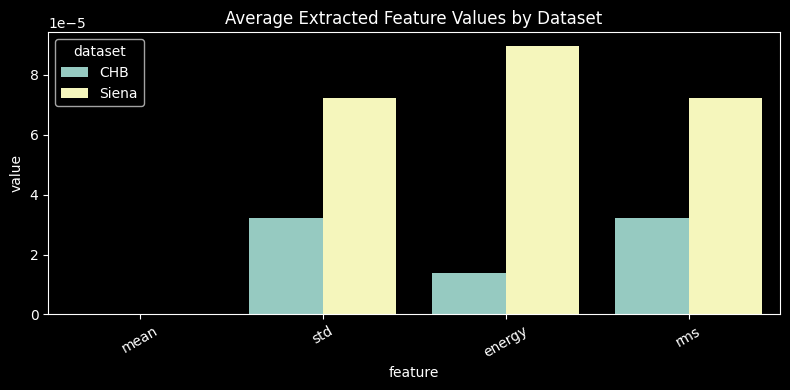

In [8]:
plt.figure(figsize=(8, 4))
sns.barplot(data=summary.melt(id_vars='dataset', var_name='feature', value_name='value'), x='feature', y='value', hue='dataset')
plt.title('Average Extracted Feature Values by Dataset')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()